In [1]:
from astropy.io import fits, ascii

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import PRF

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import auc, roc_auc_score

from astropy.cosmology import Planck18

import itertools

from imblearn.over_sampling import RandomOverSampler
from collections import Counter


In [2]:
# 'optimal' CEERS filter combinations
filter_pairs = np.array([
                         
                         ['F115W', 'F150W'],
                         ['F115W', 'F200W'],
                         
                         ['F150W', 'F200W'],
                         ['F150W', 'F277W'],
                         
                         ['F200W', 'F277W'],
                         ['F200W', 'F356W'],
                         ['F200W', 'F444W'],
                         
                         ['F277W', 'F356W'],
                         ['F277W', 'F410M'],
                         ['F277W', 'F444W'],
                         
                         ['F356W', 'F410M'],
                         ['F356W', 'F444W'],
                         
                         ['F410M', 'F444W'],
                         
                         ])

filters_select = np.array(['F277W', 'F356W', 'F444W'])

In [3]:
# galaxy models
bagpipes_models_f = ascii.read('/Users/vega/research/bagpipes_bc03_colors_z_0_20.txt')
print(bagpipes_models_f.colnames)

# brown dwarf models
bd_models_f = ascii.read('/Volumes/Vega/PRF-master/PRF/ceers_filters_ab_mag_recomp_lowz_tracks.txt')
print(bd_models_f.colnames)

['index', 'z', 'log_Mstar', 'log_SFR_100', 'Av', 'mass_w_age_Gyr', 'F435W', 'F606W', 'F775W', 'F090W', 'F115W', 'F150W', 'F182M', 'F200W', 'F210M', 'F250M', 'F277W', 'F300M', 'F335M', 'F356W', 'F410M', 'F430M', 'F444W', 'F460M', 'F480M', 'NUV', 'U', 'V', 'J', 'u_s', 'g_s', 'i_s']
['Teff_K', 'log_g', 'log_Z', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F410M', 'F444W', 'F560W', 'F770W']


In [4]:
flux_err_fit_f = ascii.read('/Volumes/Vega/PRF-master/PRF/jades_flux_err_fit.txt')
print(flux_err_fit_f.colnames)

def trunc_normal(mu, sigma, low, high):
    guess = np.random.normal(size=1, loc=mu, scale=sigma)
    
    while guess < low or guess > high:
        guess = np.random.normal(size=1, loc=mu, scale=sigma)
        
    return guess

def compute_color_err(m1, m2, f1, f2, mag_limit):
    
    # if the observed magnitude is fainter than some limit
    if m1 > mag_limit or m2 > mag_limit:
        return np.nan
    
    else:
        flux_1_nJy = 10 ** (-0.4 * (m1 - 31.4))
        flux_2_nJy = 10 ** (-0.4 * (m2 - 31.4))

        f1_idx = np.where(flux_err_fit_f['bandpass'] == f1)[0][0]
        f1_slope, f1_int, f1_nmad = flux_err_fit_f['slope'][f1_idx], flux_err_fit_f['intercept'][f1_idx], flux_err_fit_f['NMAD'][f1_idx]

        f2_idx = np.where(flux_err_fit_f['bandpass'] == f2)[0][0]
        f2_slope, f2_int, f2_nmad = flux_err_fit_f['slope'][f2_idx], flux_err_fit_f['intercept'][f2_idx], flux_err_fit_f['NMAD'][f2_idx]

        #print(f1_idx, f2_idx)

        # perturbing fluxes
        log_f1_err = f1_slope * np.log10(flux_1_nJy) + f1_int

        gauss_perturb_f1 = trunc_normal(mu=0., sigma=f1_nmad, low=-1. * f1_nmad, high=1. * f1_nmad)[0]

        f1_err_guess = 10 ** ( log_f1_err + gauss_perturb_f1 )

        log_f2_err = f2_slope * np.log10(flux_2_nJy) + f2_int

        gauss_perturb_f2 = trunc_normal(mu=0., sigma=f2_nmad, low=-1. * f2_nmad, high=1. * f2_nmad)[0]

        f2_err_guess = 10 ** ( log_f2_err + gauss_perturb_f2 )

        #print(log_f1_err, gauss_perturb_f1)

        # error on the color
        color_err_squared = ( (f1_err_guess ** 2) * ((2.5 / (np.log(10) * flux_1_nJy)) ** 2) ) + ( (f2_err_guess ** 2) * ((2.5 / (np.log(10) * flux_2_nJy)) ** 2) )

        return float( np.sqrt(color_err_squared) )

['bandpass', 'slope', 'intercept', 'NMAD']


In [15]:
%%time

mag_limit = 29.5

# star-forming galaxies

# create lists of arrays wherein each element evaluates to True or False
# if a galaxy meets the condition flux > 0 in a given filter
mask_list = []


#for f in np.unique(filter_pairs):
for f in filters_select:
    vars()['mask_%s' % f] = bagpipes_models_f['%s' % f] <= mag_limit
    
    mask_list.append(vars()['mask_%s' % f])
    
# removing galaxies with infinite magnitudes
mask_list.append(np.isfinite(bagpipes_models_f['F444W']))
mask_list.append(np.isfinite(bagpipes_models_f['F115W']))
    
flux_mask = np.asarray(mask_list).all(0)

number_of_training_galaxies = len(bagpipes_models_f[flux_mask])

print(number_of_training_galaxies)

# create data matrix
# each array of normalized colors
# will be stored in this list
data = []

for i in range(len(filter_pairs)):
    f1, f2 = filter_pairs[i][0], filter_pairs[i][1]
    
    vars()['%s_%s_color' % (f1, f2)] = (bagpipes_models_f['%s' % f1] - bagpipes_models_f['%s' % f2])[flux_mask][:]
    
    # append array of normalized colors that has been transposed to data list
    data.append( vars()['%s_%s_color' % (f1, f2)].T )
    
# turn list into array
data = np.array(data)

# take the transpose of the array
# to turn it into a matrix 
# with dimensions = (number of galaxies) x (number of colors)
data = data.T

print(data.shape)
    

# create data matrix including non-detections
data_incl_nan = []

for i in range(len(filter_pairs)):
    f1, f2 = filter_pairs[i][0], filter_pairs[i][1]
    
    vars()['%s_%s_color' % (f1, f2)] = []
    
    for j in range(len(bagpipes_models_f['%s' % f2][flux_mask])):
        m1, m2 = bagpipes_models_f['%s' % f1][flux_mask][j], bagpipes_models_f['%s' % f2][flux_mask][j]
        
        if m1 > mag_limit or m2 > mag_limit:
            vars()['%s_%s_color' % (f1, f2)].append(np.nan)
        else:
            vars()['%s_%s_color' % (f1, f2)].append(m1-m2)
            
    vars()['%s_%s_color' % (f1, f2)] = np.asarray(vars()['%s_%s_color' % (f1, f2)])
    
    # append array of normalized colors that has been transposed to data list
    data_incl_nan.append( vars()['%s_%s_color' % (f1, f2)].T )

    
# turn list into array
data_incl_nan = np.array(data_incl_nan)

# take the transpose of the array
# to turn it into a matrix 
# with dimensions = (number of galaxies) x (number of colors)
data_incl_nan = data_incl_nan.T

print(data_incl_nan.shape)
    
#data.append(bagpipes_models_f['F444W'][flux_mask][:])
    

#"""
# create matrix containing errors in colors
data_err = []

for i in range(len(bagpipes_models_f[flux_mask])):
    
    if i % 5000 == 0:
        print('Finished generating %d color errors' % i)
    
    color_errs = []
    
    for j in range(len(filter_pairs)):
        f1, f2 = filter_pairs[j][0], filter_pairs[j][1]
        
        color_err = compute_color_err(m1=bagpipes_models_f['%s' % f1][flux_mask][i],
                                      m2=bagpipes_models_f['%s' % f2][flux_mask][i],
                                      f1=f1, f2=f2, mag_limit=mag_limit)
        
        color_errs.append(color_err)
        
    color_errs = np.asarray(color_errs)
    
    data_err.append( color_errs.T )
        
# turn list into array
data_err = np.array(data_err)
#"""

# - - - BROWN DWARF MODELS - - -

# data matrix of brown dwarf models
bd_data_incl_nan = []

# randomly generated F277W magnitudes
bd_mag_1 = np.random.uniform(low=20, high=23, size=len(bd_models_f))
bd_mag_2 = np.random.uniform(low=23, high=26, size=len(bd_models_f))
bd_mag_3 = np.random.uniform(low=26, high=29.5, size=len(bd_models_f))

# brown dwarf "redshifts"
# these are used to label models as brown dwarfs below
z_bd = np.ones(len(bd_models_f) * 3) * -99.

for i in range(len(filter_pairs)):
    f1, f2 = filter_pairs[i][0], filter_pairs[i][1]
    
    vars()['%s_%s_color' % (f1, f2)] = []
    
    # brightest BD models
    for j in range(len(bd_models_f)):
        m1, m2 = bd_models_f['%s' % f1][j], bd_models_f['%s' % f2][j]
        
        #if m1 > mag_limit or m2 > mag_limit:
        #    vars()['%s_%s_color' % (f1, f2)].append(np.nan)
        #else:
        vars()['%s_%s_color' % (f1, f2)].append(m1-m2)
    
    # intermediate BD models
    for j in range(len(bd_models_f)):
        m1, m2 = bd_models_f['%s' % f1][j], bd_models_f['%s' % f2][j]
        
        #if m1 > mag_limit or m2 > mag_limit:
        #    vars()['%s_%s_color' % (f1, f2)].append(np.nan)
        #else:
        vars()['%s_%s_color' % (f1, f2)].append(m1-m2)
        
    # faintest BD models
    for j in range(len(bd_models_f)):
        m1, m2 = bd_models_f['%s' % f1][j], bd_models_f['%s' % f2][j]
        
        #if m1 > mag_limit or m2 > mag_limit:
        #    vars()['%s_%s_color' % (f1, f2)].append(np.nan)
        #else:
        vars()['%s_%s_color' % (f1, f2)].append(m1-m2)
            
    vars()['%s_%s_color' % (f1, f2)] = np.asarray(vars()['%s_%s_color' % (f1, f2)])
    
    # append array of normalized colors that has been transposed to data list
    bd_data_incl_nan.append( vars()['%s_%s_color' % (f1, f2)].T )
    
# turn list into array
bd_data_incl_nan = np.array(bd_data_incl_nan)

# take the transpose of the array
# to turn it into a matrix 
# with dimensions = (number of galaxies) x (number of colors)
bd_data_incl_nan = bd_data_incl_nan.T

print(bd_data_incl_nan.shape)
    
# create matrix containing errors in colors
bd_data_err = []

# brightest BD models
for i in range(len(bd_models_f)):
    
    color_errs = []
    
    f277w_mag = bd_mag_1[i]
    
    for j in range(len(filter_pairs)):
        f1, f2 = filter_pairs[j][0], filter_pairs[j][1]
        
        col1 = bd_models_f[f1][i] - bd_models_f['F277W'][i]
        m1 = f277w_mag + col1
        
        col2 = bd_models_f[f2][i] - bd_models_f['F277W'][i]
        m2 = f277w_mag + col2
        
        
        color_err = compute_color_err(m1=m1,
                                      m2=m2,
                                      f1=f1, f2=f2, mag_limit=mag_limit)
        
        color_errs.append(color_err)
        
    color_errs = np.asarray(color_errs)
    
    bd_data_err.append( color_errs.T )
    
# intermediate BD models
for i in range(len(bd_models_f)):
    
    color_errs = []
    
    f277w_mag = bd_mag_2[i]
    
    for j in range(len(filter_pairs)):
        f1, f2 = filter_pairs[j][0], filter_pairs[j][1]
        
        col1 = bd_models_f[f1][i] - bd_models_f['F277W'][i]
        m1 = f277w_mag + col1
        
        col2 = bd_models_f[f2][i] - bd_models_f['F277W'][i]
        m2 = f277w_mag + col2
        
        
        color_err = compute_color_err(m1=m1,
                                      m2=m2,
                                      f1=f1, f2=f2, mag_limit=mag_limit)
        
        color_errs.append(color_err)
        
    color_errs = np.asarray(color_errs)
    
    bd_data_err.append( color_errs.T )
    
# faintest BD models
for i in range(len(bd_models_f)):
    
    color_errs = []
    
    f277w_mag = bd_mag_3[i]
    
    for j in range(len(filter_pairs)):
        f1, f2 = filter_pairs[j][0], filter_pairs[j][1]
        
        col1 = bd_models_f[f1][i] - bd_models_f['F277W'][i]
        m1 = f277w_mag + col1
        
        col2 = bd_models_f[f2][i] - bd_models_f['F277W'][i]
        m2 = f277w_mag + col2
        
        
        color_err = compute_color_err(m1=m1,
                                      m2=m2,
                                      f1=f1, f2=f2, mag_limit=mag_limit)
        
        color_errs.append(color_err)
        
    color_errs = np.asarray(color_errs)
    
    bd_data_err.append( color_errs.T )
        
# turn list into array
bd_data_err = np.array(bd_data_err)

# concatenate data_incl_nan and bd_data_incl_nan
data_incl_nan = np.concatenate([data_incl_nan, bd_data_incl_nan], axis=0)

# concatenate data_err and bd_data_err
data_err = np.concatenate([data_err, bd_data_err])

# arrays of physical properties
z_models = np.concatenate([bagpipes_models_f['z'][flux_mask], z_bd])
#ssfr_models = (bagpipes_models_f['log_SFR_100'] - bagpipes_models_f['log_Mstar'])[flux_mask]
#tauv_models = bagpipes_models_f['Av'][flux_mask]
#mstar_models = bagpipes_models_f['log_Mstar'][flux_mask]
    
print('Shape of training data matrix:', data_incl_nan.shape)
print('Shape of training data error matrix:', data_err.shape)

11666
(11666, 13)


<timed exec>:34: RuntimeWarning: invalid value encountered in subtract


(11666, 13)
Finished generating 0 color errors
Finished generating 5000 color errors
Finished generating 10000 color errors
(1980, 13)
Shape of training data matrix: (13646, 13)
Shape of training data error matrix: (13646, 13)
CPU times: user 1min 12s, sys: 177 ms, total: 1min 13s
Wall time: 1min 13s


(13646, 13)
(13646, 13)


In [11]:
print(bd_data_err.shape)

(1980, 13)


In [28]:
print(data_incl_nan)

[[    nan     nan  2.3298 ...  0.0639  0.1272  0.0633]
 [    nan     nan -0.0107 ...  0.4086  0.3295 -0.0791]
 [ 0.3679  0.608   0.2401 ... -0.1869 -0.2875 -0.1006]
 ...
 [-0.0115  0.2733  0.2848 ...  0.1696  0.1494 -0.0202]
 [ 0.3249  0.4636  0.1387 ... -0.0867  0.0299  0.1166]
 [    nan     nan     nan ...  0.0188  0.056   0.0372]]


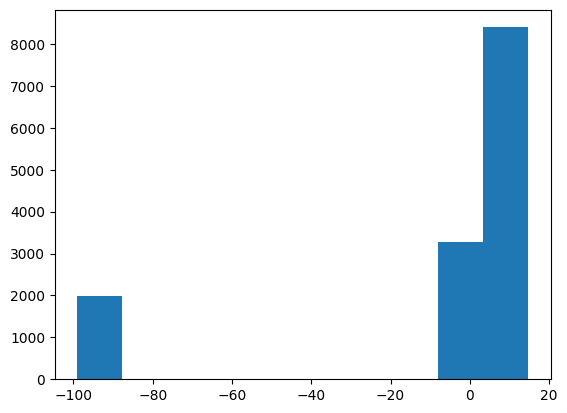

In [16]:
plt.hist(z_models)
plt.show()

### create redshift-based classifications

In [17]:
z_0_2_crit = np.where( (z_models >= 0.) & (z_models < 2.) )[0]

z_2_4_crit = np.where( (z_models >= 2.) & (z_models < 4.) )[0]

z_4_6_crit = np.where( (z_models >= 4.) & (z_models < 6.) )[0]

z_6_8_crit = np.where( (z_models >= 6.) & (z_models < 8.) )[0]

z_8_10_crit = np.where( (z_models >= 8.) & (z_models < 10.) )[0]

z_10_15_crit = np.where( (z_models >= 10.) & (z_models < 15.) )[0]

z_15_20_crit = np.where( (z_models >= 15.) & (z_models < 20.) )[0]

bd_crit = np.where(z_models == -99.)[0]

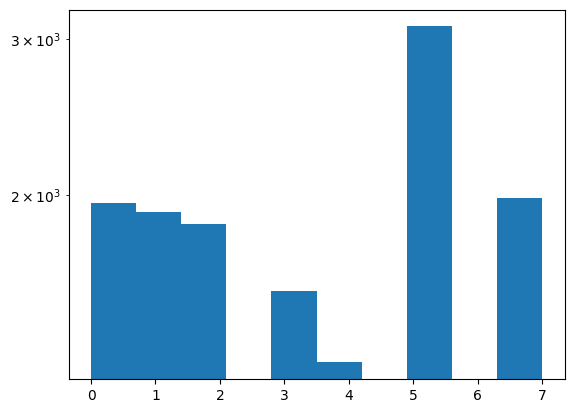

[5. 4. 0. ... 7. 7. 7.]


In [18]:
labels = np.zeros(len(z_models))

for i in z_0_2_crit:
    labels[i] = 0

for i in z_2_4_crit:
    labels[i] = 1
    
for i in z_4_6_crit:
    labels[i] = 2
    
for i in z_6_8_crit:
    labels[i] = 3
    
for i in z_8_10_crit:
    labels[i] = 4

for i in z_10_15_crit:
    labels[i] = 5

for i in z_15_20_crit:
    labels[i] = 6
    
for i in bd_crit:
    labels[i] = 7
        
plt.hist( labels, log=True )
plt.show()

print(labels)

### create a training set

In [27]:
# following advice from https://builtin.com/data-science/numpy-random-seed,
# a random number generator for this specific task is created

split_sample_rng = np.random.default_rng(2015)

random_80_percent = split_sample_rng.choice(a=data_incl_nan.shape[0], size=int(0.8 * data_incl_nan.shape[0]), replace=False )

# a simple way to select elements in an array that are NOT those in another subset of the same array
# https://stackoverflow.com/questions/64759986/how-to-get-the-remaining-indexes-after-a-random-set-of-indexes-is-selected-in-py

random_20_percent = [x for x in range(0, data_incl_nan.shape[0]) if x not in random_80_percent]

print(random_80_percent[:10])
print(random_20_percent[:10])

print('There are %d galaxies in the training set (80 percent of the sample)' % len(random_80_percent))
print('There are %d galaxies in the testing set (20 percent of the sample)' % len(random_20_percent))


[ 2889  8371  9370  2106  3115 10620  9641  9819   648  9888]
[1, 2, 5, 6, 10, 18, 20, 21, 22, 24]
There are 10916 galaxies in the training set (80 percent of the sample)
There are 2730 galaxies in the testing set (20 percent of the sample)


### resample training set to correct for imbalanced classes

In [29]:
ros = RandomOverSampler(random_state=2015)
#data_resampled, labels_resampled = ros.fit_resample(data[random_80_percent], labels[random_80_percent])
data_incl_nan_resampled, labels_resampled = ros.fit_resample(data_incl_nan[random_80_percent], labels[random_80_percent])
data_err_resampled, labels_resampled_ = ros.fit_resample(data_err[random_80_percent], labels[random_80_percent])


(14760, 13)
[[ 0.0208  0.3794  0.3586 ... -0.0399  0.0762  0.1161]
 [ 0.334   0.57    0.236  ... -0.1834 -0.3385 -0.1551]
 [ 1.1671  1.8493  0.6822 ...  0.2548  0.3876  0.1328]
 ...
 [ 1.3436  1.4503  0.1067 ...  0.4002  0.4664  0.0662]
 [ 2.5418  3.8345  1.2927 ...  0.8223  1.0485  0.2262]
 [ 2.2578  3.0636  0.8058 ...  0.811   1.0697  0.2587]]


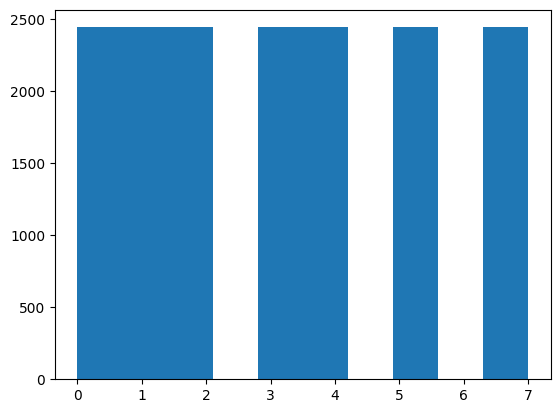

In [30]:
print(data_resampled.shape)

print(data_resampled)

plt.hist(labels_resampled, bins=10)
plt.show()


### run a standard random forest

In [13]:
%%time
rf = RandomForestClassifier(n_estimators=50, bootstrap=True)
#rf.fit(data[random_80_percent], labels[random_80_percent])

rf.fit(data_resampled, labels_resampled)



CPU times: user 1.73 s, sys: 5.94 ms, total: 1.73 s
Wall time: 1.74 s


RandomForestClassifier(n_estimators=50)

In [34]:
def compute_completeness_purity(cm, i):
    print( 'Completeness:', cm[i,i] / (np.sum(cm[i,:])) )
    print( 'Purity:', cm[i,i] / (np.sum(cm[:,i])) )

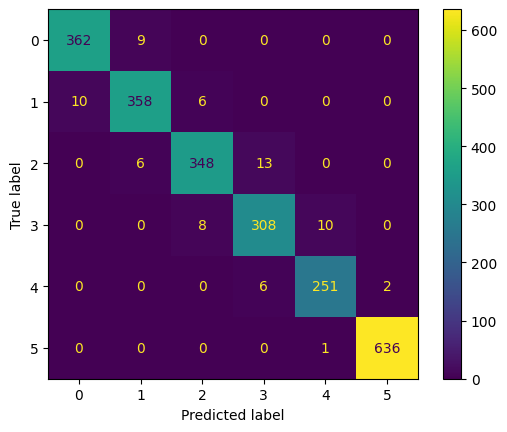

Completeness: 0.9984301412872841
Purity: 0.9968652037617555
Accuracy: 0.9695801199657241
Precision: 0.9695717609458951
Recall: 0.9695801199657241


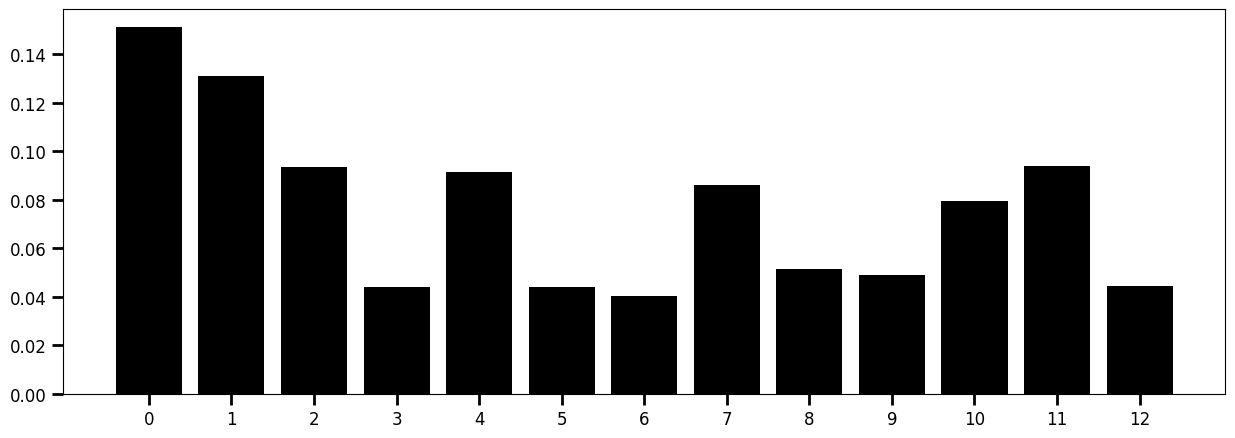

In [15]:
labels_pred = rf.predict(data[random_20_percent])

# Create the confusion matrix
cm = confusion_matrix(labels[random_20_percent], labels_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();
plt.show()

compute_completeness_purity(cm=cm, i=5)
#compute_completeness_purity(cm=cm, i=6)


#print(cm)

accuracy = accuracy_score(labels[random_20_percent], labels_pred)
precision = precision_score(labels[random_20_percent], labels_pred, average='weighted')
recall = recall_score(labels[random_20_percent], labels_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

# feature importances
importances = rf.feature_importances_
std = np.std([rf.feature_importances_ for tree in rf.estimators_], axis=0)

x_plot = range(data.shape[1])

fig = plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)

plt.bar(x_plot, importances, color='k', yerr=std)
plt.gca().set_xticks(x_plot)
#plt.gca().set_xticklabels(['%s' % f for f in filter_pairs

#plt.gca().set_xticklabels(['%s' % f for f in [
#                                             'F115W-F150W',
#                                             'F150W-F200W',
#                                             'F150W-F277W',
#                                             'F200W-F277W',
#                                             'F277W-F410M',
#                                             'F277W-F444W',
#                                             'F356W-F444W']], rotation=30)

plt.tick_params(labelsize=12, length=8, width=2)

#plt.xlim(-0.5, 26.5)

plt.show()

#print( roc_auc_score(labels[random_20_percent], labels_pred, multi_class='ovr') )


### tuning hyperparameters

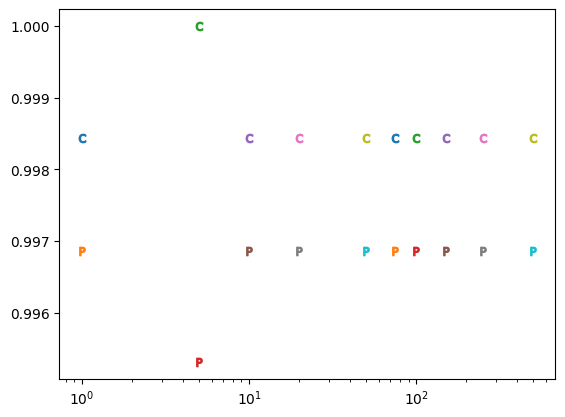

In [24]:
n_trees = [1, 5, 10, 20, 50, 75, 100, 150, 250, 500]

#completeness = []
#purity = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, bootstrap=True, max_features=data.shape[1], )
    rf.fit(data_resampled, labels_resampled)

    #rf.fit(data[random_80_percent], labels[random_80_percent])
    
    j = 5
    
    labels_pred = rf.predict(data[random_20_percent])

    # Create the confusion matrix
    cm = confusion_matrix(labels[random_20_percent], labels_pred)
    
    comp = cm[j,j] / (np.sum(cm[j,:]))
    pure = cm[j,j] / (np.sum(cm[:,j]))
    
    plt.scatter( n, comp, marker=r'$\rm{C}$' )
    plt.scatter( n, pure, marker=r'$\rm{P}$' )
    
plt.xscale('log')
    
plt.show()



### train PRF

In [31]:
%%time
n_trees = 50
prf_cls = PRF.prf(n_estimators=n_trees, bootstrap=True)

prf_cls.fit(X=data_incl_nan_resampled, dX=data_err_resampled, y=labels_resampled)

CPU times: user 36.7 s, sys: 194 ms, total: 36.9 s
Wall time: 36.9 s


ProbabilisticRandomForestClassifier(n_estimators_='50', criterion='gini', max_features='auto', max_depth='None', keep_proba='0.05', bootstrap='True', min_py_sum_leaf='1', n_jobs='1', n_features_='13', feature_importances_='[0.02607361 0.01648211 0.04338039 0.04638664 0.07981234 0.03652815
 0.02101436 0.06715554 0.0599199  0.03657005 0.11579875 0.10491474
 0.11484609]', max_features_num='3', unsupervised='False', n_classes_='7')

### perturb test set

In [32]:
print(data_incl_nan[random_20_percent].shape)

print(data_incl_nan[random_20_percent][0], data_err[random_20_percent][0])

data_rnd20_perturb = []

for i in range(data_incl_nan[random_20_percent].shape[0]):
    
    rnd_arr = np.zeros(data_incl_nan[random_20_percent].shape[1])
    
    for j in range(data_incl_nan[random_20_percent].shape[1]):
        if np.isnan(data_incl_nan[random_20_percent][i][j]):
            rnd_arr[j] = 0.
        else:
            rnd_arr[j] = np.random.normal(size=1, loc=0, scale=data_err[random_20_percent][i][j])
    
    data_rnd20_perturb.append(data_incl_nan[random_20_percent][i] + rnd_arr)
    
data_rnd20_perturb = np.asarray(data_rnd20_perturb)

print(data_rnd20_perturb.shape)


(2730, 13)
[    nan     nan -0.0107 -0.0911 -0.0804 -0.1135  0.216  -0.0331  0.3755
  0.2964  0.4086  0.3295 -0.0791] [       nan        nan 0.19905712 0.14147322 0.14346927 0.14915489
 0.12677065 0.08827886 0.11015817 0.10044794 0.09072619 0.09182933
 0.11574256]


/var/folders/1_/ykm0yg054jz_l14h_2fqwfnm0000gn/T/ipykernel_40103/4201141696.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rnd_arr[j] = np.random.normal(size=1, loc=0, scale=data_err[random_20_percent][i][j])


(2730, 13)


keep probability: 0.05
Completeness: 0.650381679389313
Purity: 0.8623481781376519


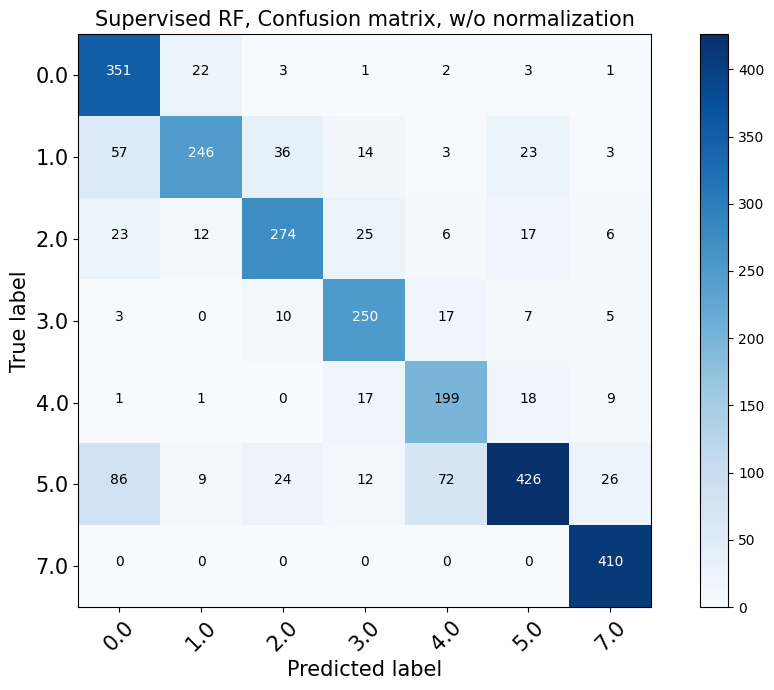

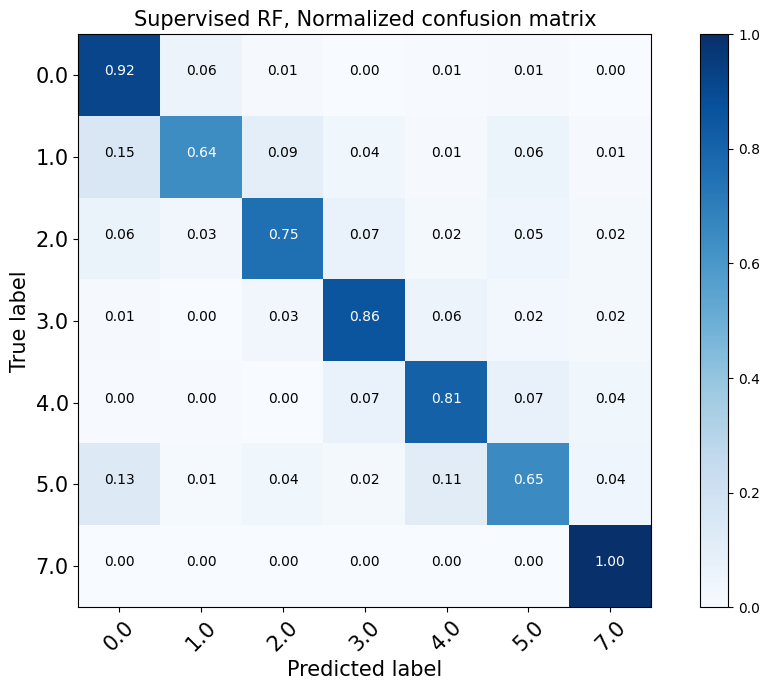

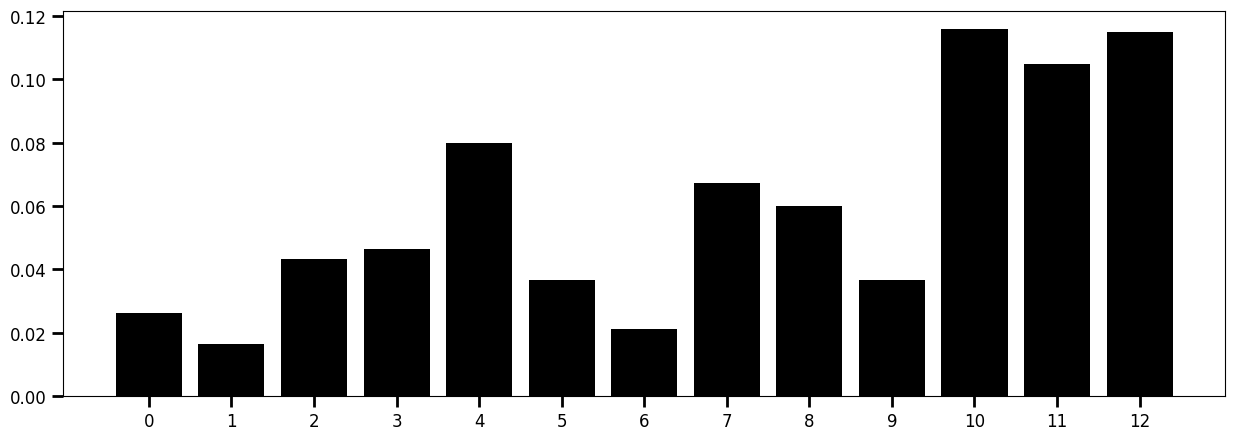

In [35]:
pred = prf_cls.predict(data_rnd20_perturb, dX=data_err[random_20_percent])

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        #print("Normalized confusion matrix")
#    else:
        #print('Confusion matrix, without normalization')

    #print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize = 15)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize = 15)
    plt.yticks(tick_marks, classes, fontsize = 15)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label', fontsize = 15)
    plt.xlabel('Predicted label', fontsize = 15)
    plt.tight_layout()

cnf_matrix = confusion_matrix(labels[random_20_percent], pred)

# Plot non-normalized confusion matrix
print('keep probability:', prf_cls.keep_proba)

plt.figure(figsize = (10,7))
plot_confusion_matrix(cnf_matrix, classes=[str(i) for i in np.unique(labels)],
                      title='Supervised RF, Confusion matrix, w/o normalization')

compute_completeness_purity(cm=cnf_matrix, i=5)

# Plot normalized confusion matrix
plt.figure(figsize = (10,7))
plot_confusion_matrix(cnf_matrix, classes=[str(i) for i in np.unique(labels)], normalize=True,
                      title='Supervised RF, Normalized confusion matrix')

plt.show()

importances = prf_cls.feature_importances_

x_plot = range(data.shape[1])

fig = plt.figure()
fig.set_figwidth(15)
fig.set_figheight(5)

plt.bar(x_plot, importances, color='k')
plt.gca().set_xticks(x_plot)

plt.tick_params(labelsize=12, length=8, width=2)

#plt.xlim(-0.5, 26.5)

plt.show()

